In [15]:
import pandas as pd
import os
import matplotlib.pyplot as plt


In [16]:

#Calculate the Sprint Pose Fitness Score (SPFS)
STATUSES = ['blurry', 'blurry_occluded', 'normal', 'occluded']

PHASES = ['close', 'far','accel','maxV']

SCORES = ['Correct (C) %', 'False (F) %', "Don't Know (DK) %"]

compare_dir = '../comparison_final'
kp = '/keypoints'
agl = '/angles'

# Initialize empty DataFrames for each method
mediapipe_summary = pd.DataFrame(columns=['Phase', 'Status', 'Type', 'Correct (C) %', 'False (F) %', "Don't Know (DK) %"])
mmpose_summary = pd.DataFrame(columns=['Phase', 'Status', 'Type', 'Correct (C) %', 'False (F) %', "Don't Know (DK) %"])
yolo_summary = pd.DataFrame(columns=['Phase', 'Status', 'Type', 'Correct (C) %', 'False (F) %', "Don't Know (DK) %"])

# Function to process files and append to the appropriate method DataFrame
def process_files_by_method(type, method_summaries):
    for phase in PHASES:
        for status in STATUSES:
            # Construct the file path
            file_path = f'{compare_dir}{type}/{phase}/info/CFDK/PK_{status}.csv'
            if not os.path.exists(file_path):
                print(f"File not found: {file_path}")
                continue
            # Read the file into a DataFrame
            df = pd.read_csv(file_path)
            
            # Add Phase, Status, and Type columns
            df['Phase'] = phase

            if status == 'normal':
                df['Status'] = 'Normal'
            elif status == 'occluded':
                df['Status'] = 'Occluded'
            elif status == 'blurry':
                df['Status'] = 'Blurry'
            elif status == 'blurry_occluded':
                df['Status'] = 'Blurry and Occluded'

            df['Type'] = 'Keypoints' if type == kp else 'Angles'
            
            # Append to the appropriate method DataFrame
            for method in ['Mediapipe', 'MMPose', 'YOLO']:
                method_df = df[df['Method'] == method]
                if method == 'Mediapipe':
                    method_summaries['Mediapipe'] = pd.concat([method_summaries['Mediapipe'], method_df], ignore_index=True)
                elif method == 'MMPose':
                    method_summaries['MMPose'] = pd.concat([method_summaries['MMPose'], method_df], ignore_index=True)
                elif method == 'YOLO':
                    method_summaries['YOLO'] = pd.concat([method_summaries['YOLO'], method_df], ignore_index=True)

# Process keypoints and angles files for each method
method_summaries = {'Mediapipe': mediapipe_summary, 'MMPose': mmpose_summary, 'YOLO': yolo_summary}
process_files_by_method(kp, method_summaries)
process_files_by_method(agl, method_summaries)

# Assign the updated summaries back to the respective variables
mediapipe_scores = method_summaries['Mediapipe']
mmpose_scores = method_summaries['MMPose']
yolo_scores = method_summaries['YOLO']




File not found: ../comparison_final/keypoints/far/info/CFDK/PK_blurry_occluded.csv
File not found: ../comparison_final/keypoints/accel/info/CFDK/PK_blurry_occluded.csv


In [17]:
print(yolo_scores)

    Phase               Status       Type  Correct (C) %  False (F) %  \
0   close               Blurry  Keypoints      36.666667    46.666667   
1   close  Blurry and Occluded  Keypoints      40.000000    60.000000   
2   close               Normal  Keypoints      50.000000    33.333333   
3   close             Occluded  Keypoints     100.000000     0.000000   
4     far               Blurry  Keypoints       0.000000     0.000000   
5     far               Normal  Keypoints       0.000000     0.000000   
6     far             Occluded  Keypoints       0.000000     0.000000   
7   accel               Blurry  Keypoints      30.434783    47.826087   
8   accel               Normal  Keypoints      46.341463    41.463415   
9   accel             Occluded  Keypoints      66.666667    33.333333   
10   maxV               Blurry  Keypoints      31.034483    51.724138   
11   maxV  Blurry and Occluded  Keypoints      62.500000    37.500000   
12   maxV               Normal  Keypoints      69.5

In [19]:
yolo_scores.groupby("Phase")["Correct (C) %"].mean()

Phase
accel    34.332697
close    46.770833
far       0.000000
maxV     36.835914
Name: Correct (C) %, dtype: float64

**WES_point**	Score per joint or angle (per frame)	Analyze specific joints like knees or hips<br><br>
**WES_frame**	Average score of all joints/angles in a single frame	Evaluate frame-level pose quality<br><br>
**WES_phase**	Average over all frames within a sprint phase (e.g. Accel)	Compare Accel vs MaxV<br><br>
**WES_env**	Average over camera distance (e.g. Close vs Far)	Test environmental robustness<br><br>
**WES_condition**	Average based on blur/occlusion condition	Impact of blur/occlusion on accuracy<br><br>
**WES_model**	Average across all predictions from one model	Compare MediaPipe vs YOLO vs MMPose<br><br>
**WES_joint_type**	Avg score for a specific joint (e.g. all left ankles)	Identify which joints suffer most in poor conditions<br><br>

In [ ]:
categories = {
    "WES_phase": "Phase", 
    "WES_status": "Status",
    "WES_type": "Type",
}

# Add logic to ignore the "close/maxV" phase and aggregate it separately
def calculate_sums_with_ignore(scores_df, category_key):
        return scores_df.groupby(categories[category_key])[SCORES].mean()
    


for category in categories:
    print(f"Category: {category}")
    print("Mediapipe Scores:")
    print(calculate_sums_with_ignore(mediapipe_scores, category))
    print("\nMMPose Scores:")
    print(calculate_sums_with_ignore(mmpose_scores, category))
    print("\nYOLO Scores:")
    print(calculate_sums_with_ignore(yolo_scores, category))
    print("\n" + "-"*55 + "\n")

# Summation of everything 
print("Summation of Everything:")
print("Mediapipe Scores:")
print(mediapipe_scores[SCORES].mean())
print("\nMMPose Scores:")
print(mmpose_scores[SCORES].mean())
print("\nYOLO Scores:")
print(yolo_scores[SCORES].mean())
print("\n" + "="*55 + "\n")
# Calculate the mean of Correct (C) % for each model across Phase, Status, Type, and All
summary_data = {
    "Model": ["MediaPipe", "MMPose", "YOLO"],
    "Phase": [#accel,maxv,far,close
        mediapipe_scores.groupby("Phase")["Correct (C) %"].mean(),
        mmpose_scores.groupby("Phase")["Correct (C) %"].mean(),
        yolo_scores.groupby("Phase")["Correct (C) %"].mean(),
    ],
    "Status": [#normal,occluded,blurry,blurry_occluded
        mediapipe_scores.groupby("Status")["Correct (C) %"].mean(),
        mmpose_scores.groupby("Status")["Correct (C) %"].mean(),
        yolo_scores.groupby("Status")["Correct (C) %"].mean(),
    ],
    "Type": [#keypoints,angles
        mediapipe_scores.groupby("Type")["Correct (C) %"].mean(),
        mmpose_scores.groupby("Type")["Correct (C) %"].mean(),
        yolo_scores.groupby("Type")["Correct (C) %"].mean(),
    ],
    "All": [
        mediapipe_scores["Correct (C) %"].mean(),
        mmpose_scores["Correct (C) %"].mean(),
        yolo_scores["Correct (C) %"].mean(),
    ],
}

# Create a DataFrame for the summary
summary_df = pd.DataFrame(summary_data)

# Display the summary DataFrame
print(summary_df)
summary_df.to_csv('CFDK.csv')

Category: WES_phase
Mediapipe Scores:
       Correct (C) %  False (F) %  Don't Know (DK) %
Phase                                               
accel      58.820647    41.179353           0.000000
close      31.640625    55.494792          12.864583
far         0.000000     0.000000         100.000000
maxV       18.323821    64.205624          17.470554

MMPose Scores:
       Correct (C) %  False (F) %  Don't Know (DK) %
Phase                                               
accel      82.190531    17.809469                0.0
close      69.231771    30.768229                0.0
far        68.537415    31.462585                0.0
maxV       51.110240    48.889760                0.0

YOLO Scores:
       Correct (C) %  False (F) %  Don't Know (DK) %
Phase                                               
accel      34.332697    52.298250          13.369054
close      46.770833    38.710938          14.518229
far         0.000000     0.000000         100.000000
maxV       36.835914    45.9150

Plotting Combined Scores for Category: Phase (Correct (C) %)
Combining scores for WES_phase - Combined Scores - Phase (Correct (C) %)


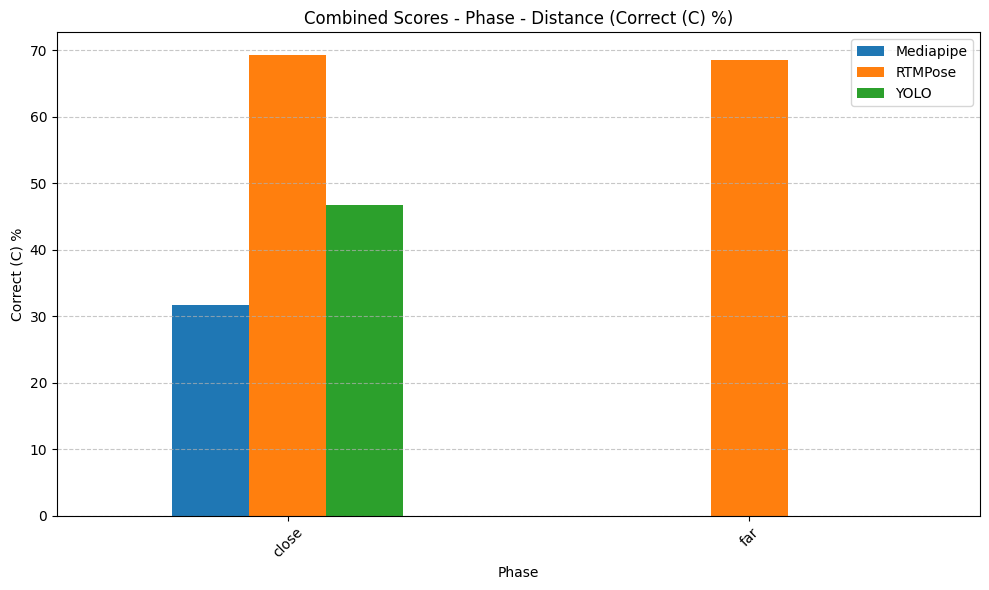

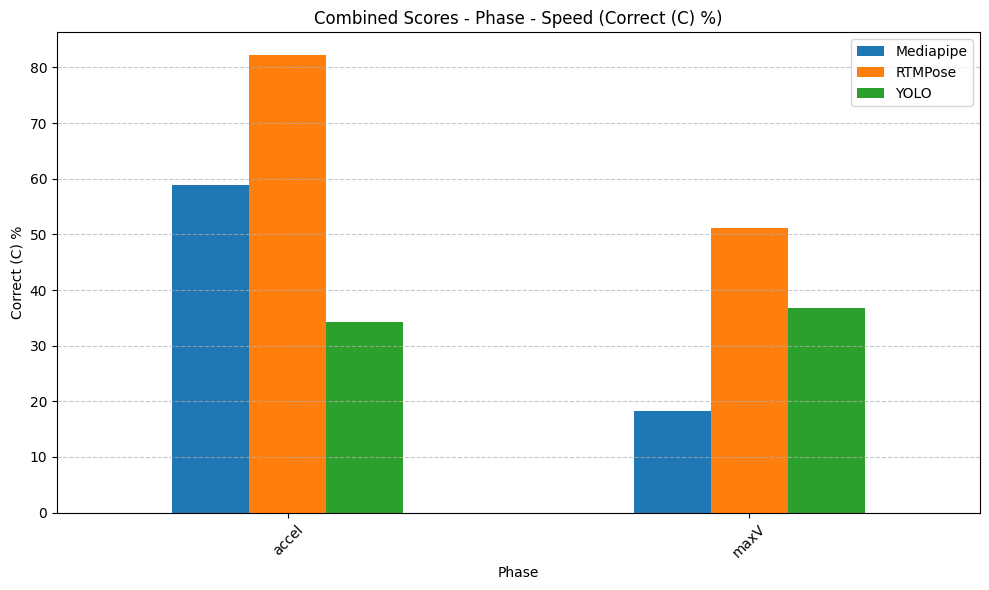

Plotting Combined Scores for Category: Phase (False (F) %)
Combining scores for WES_phase - Combined Scores - Phase (False (F) %)


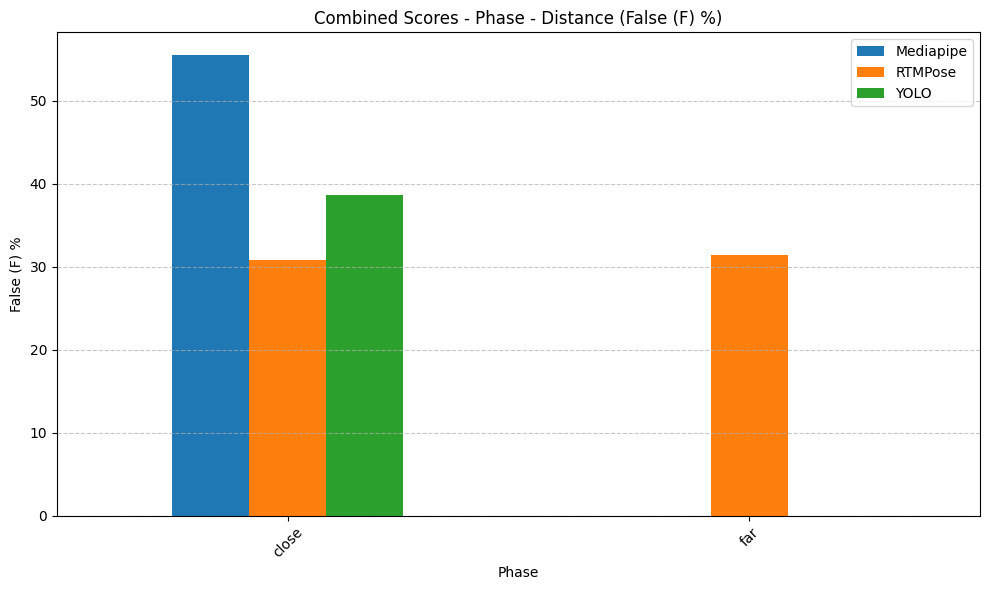

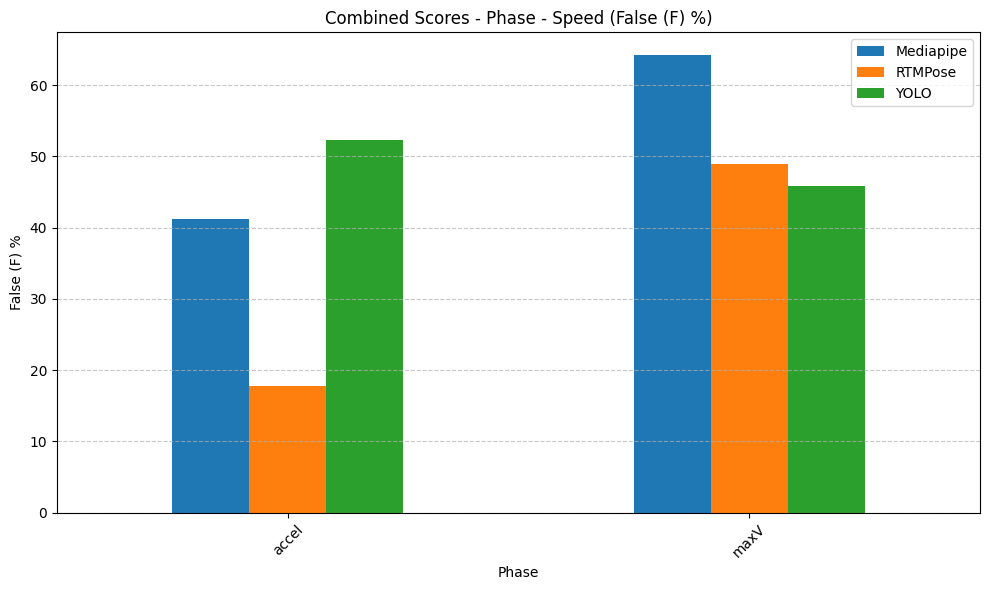

Plotting Combined Scores for Category: Phase (Don't Know (DK) %)
Combining scores for WES_phase - Combined Scores - Phase (Don't Know (DK) %)


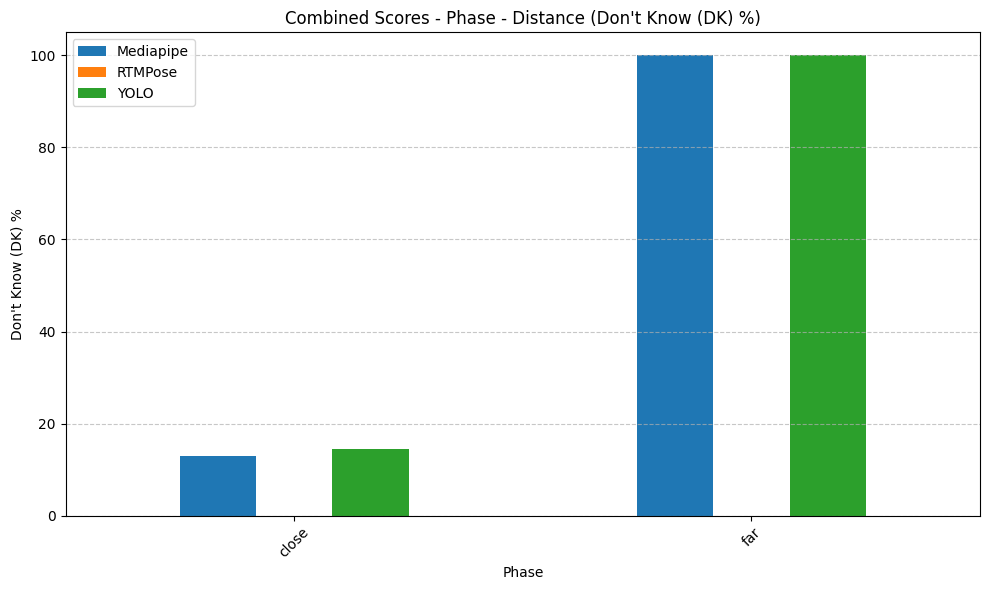

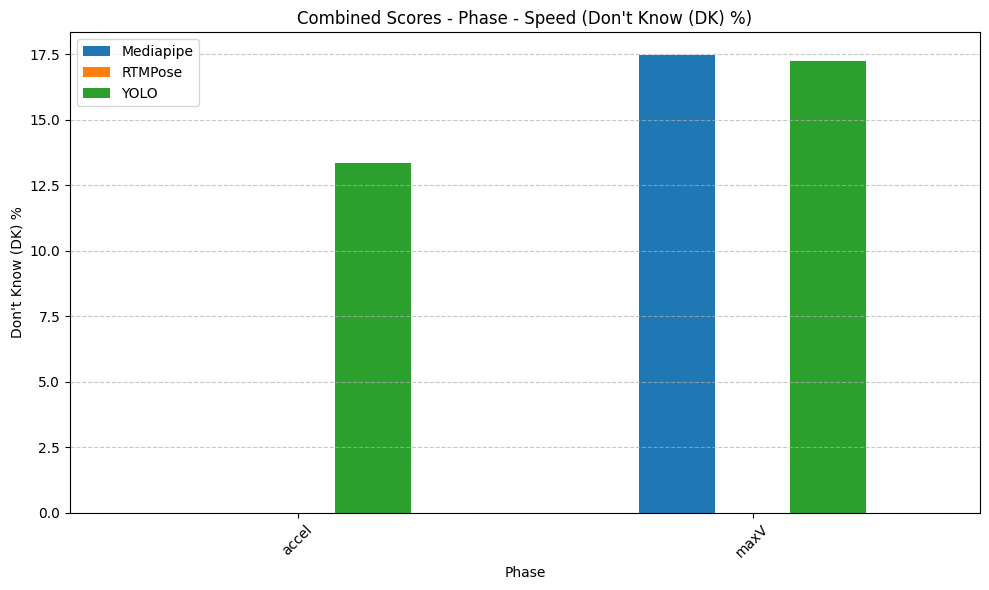

Plotting Combined Scores for Category: Status (Correct (C) %)
Combining scores for WES_status - Combined Scores - Status (Correct (C) %)


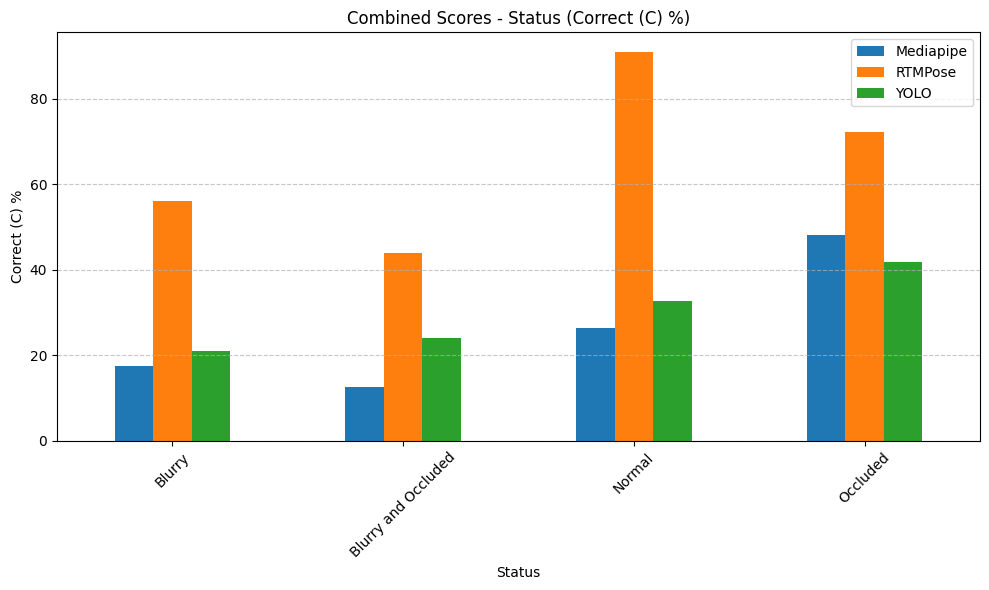

Plotting Combined Scores for Category: Status (False (F) %)
Combining scores for WES_status - Combined Scores - Status (False (F) %)


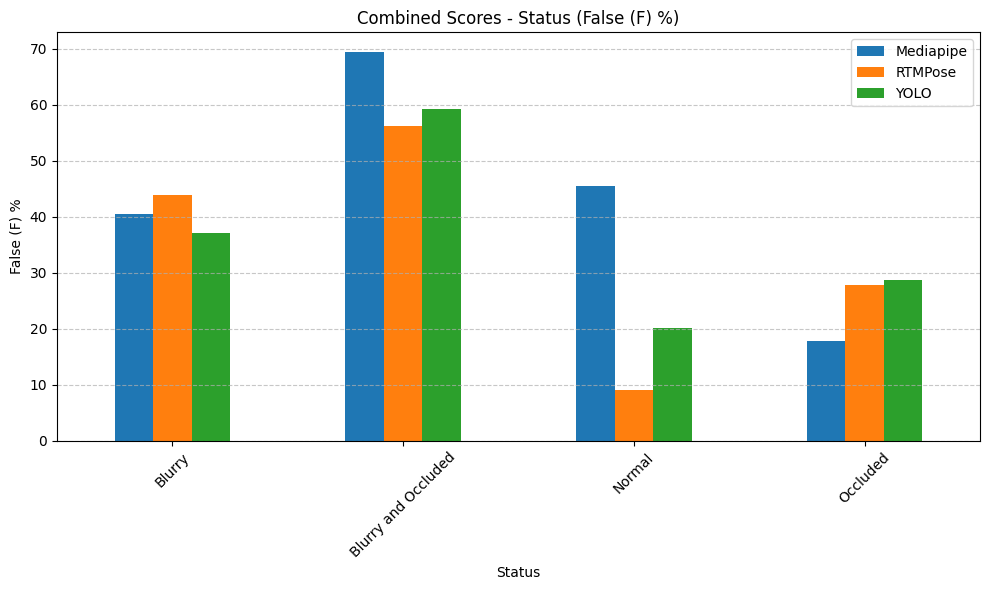

Plotting Combined Scores for Category: Status (Don't Know (DK) %)
Combining scores for WES_status - Combined Scores - Status (Don't Know (DK) %)


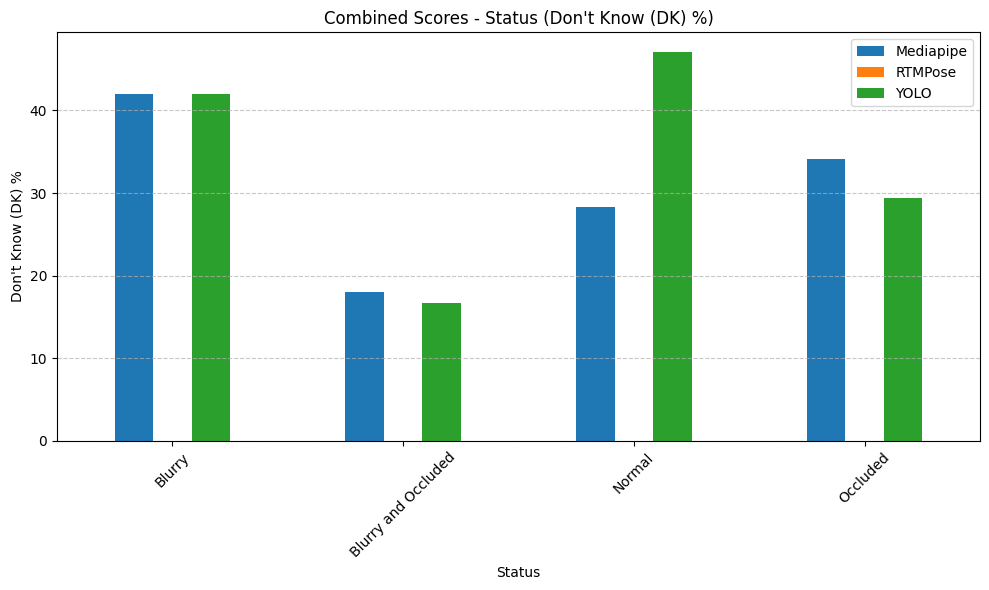

Plotting Combined Scores for Category: Type (Correct (C) %)
Combining scores for WES_type - Combined Scores - Type (Correct (C) %)


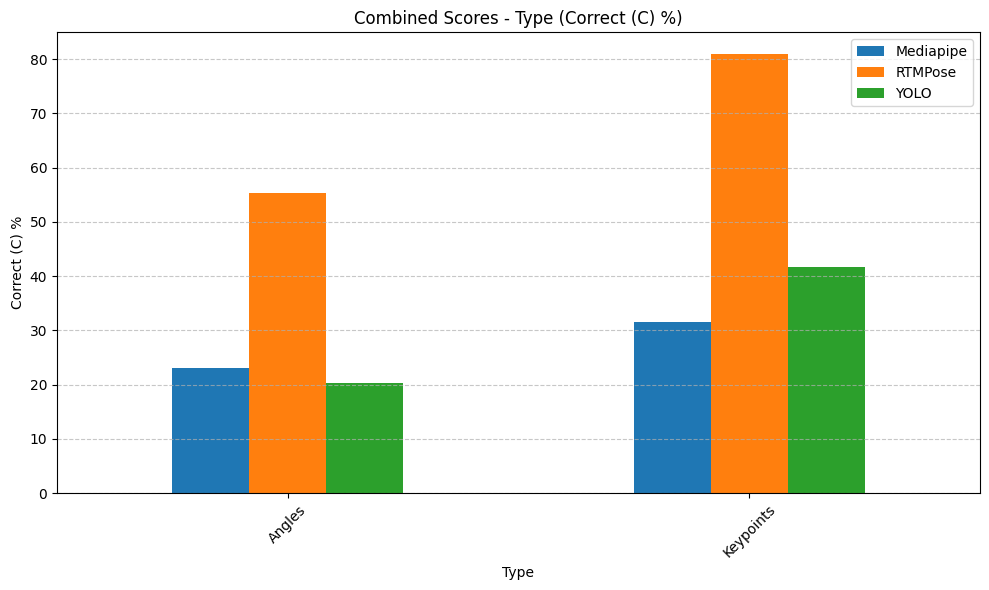

Plotting Combined Scores for Category: Type (False (F) %)
Combining scores for WES_type - Combined Scores - Type (False (F) %)


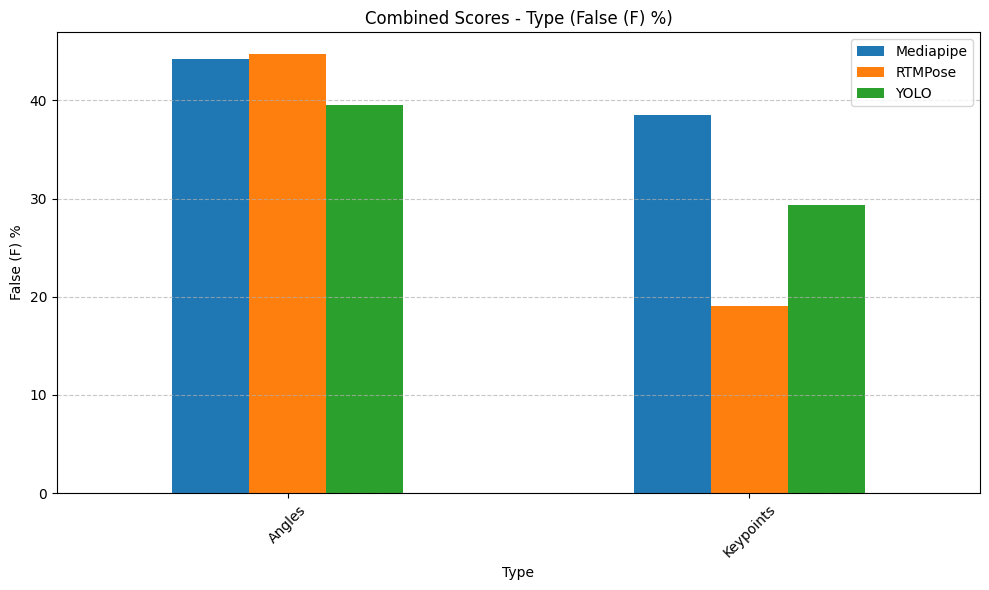

Plotting Combined Scores for Category: Type (Don't Know (DK) %)
Combining scores for WES_type - Combined Scores - Type (Don't Know (DK) %)


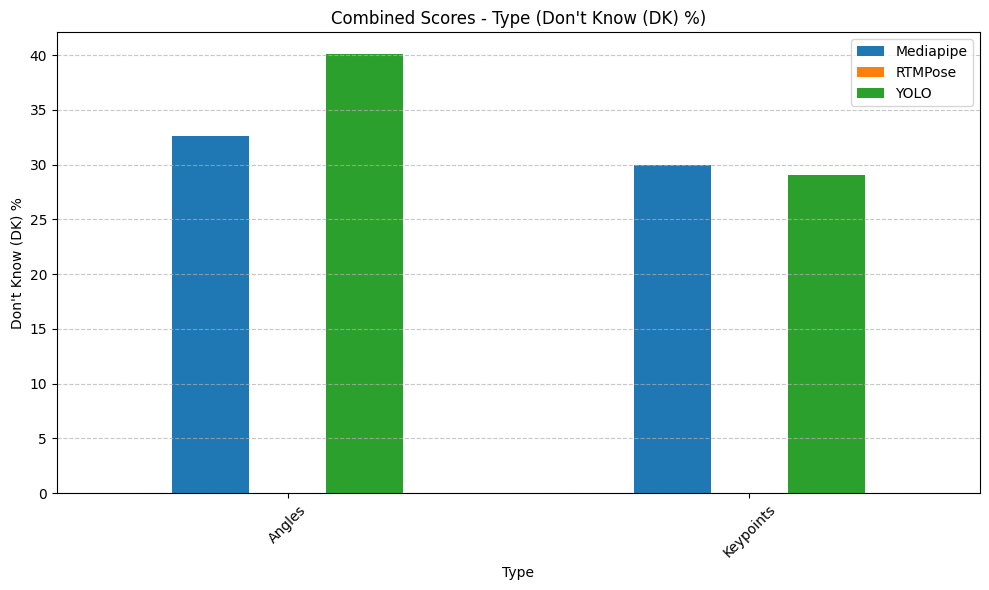

Plotting Combined Scores for All Categories (Don't Know (DK) %):


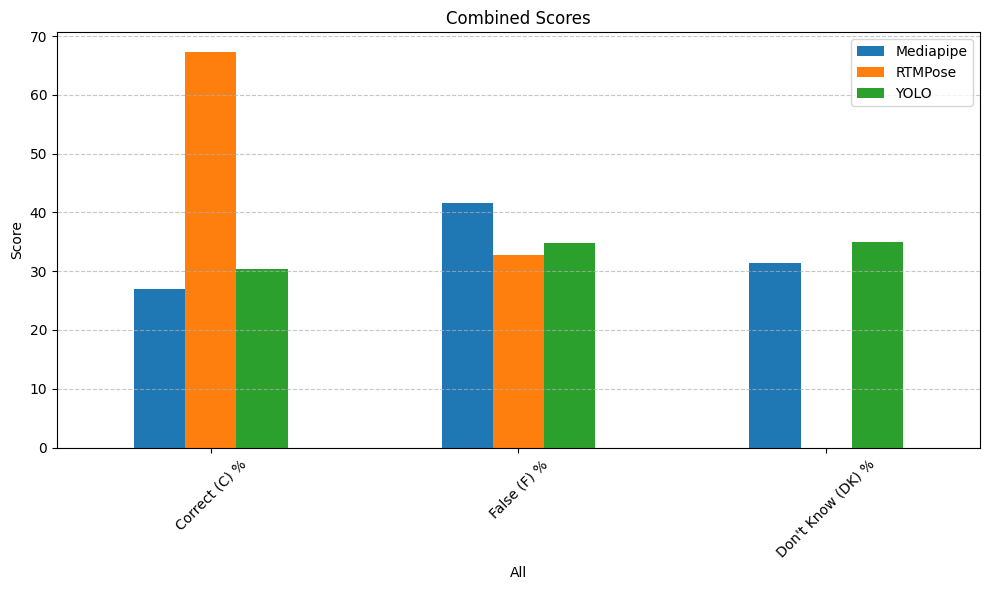

In [12]:
dir = '../results'
datapath = os.path.join(dir, 'P_data')
plotpath = os.path.join(dir, 'P_plots')

os.makedirs(dir, exist_ok=True)
os.makedirs(datapath, exist_ok=True)
os.makedirs(plotpath, exist_ok=True)
    

#Plot scores for each category and model
# for category in categories:
#     print(f"Plotting for Category: {categories[category]}")
#     print("Mediapipe Scores:")
#     plot_scores(mediapipe_scores, category, f"Mediapipe Scores - {categories[category]}")
#     print("\nMMPose Scores:")
#     plot_scores(mmpose_scores, category, f"MMPose Scores - {categories[category]}")
#     print("\nYOLO Scores:")
#     plot_scores(yolo_scores, category, f"YOLO Scores - {categories[category]}")

# print("Summation of Everything:")
# print("Mediapipe Scores:")
# plot_scores(mediapipe_scores, 'All', f"Mediapipe Scores - All")
# print("\nMMPose Scores:")
# plot_scores(mmpose_scores, 'All', f"MMPose Scores - All")
# print("\nYOLO Scores:")
# plot_scores(yolo_scores, 'All', f"YOLO Scores - All")

# Combine scores from all models into a single DataFrame for comparison
def combine_and_plot_all_models(category_key, title, score_type,combined_scores=None):

    if combined_scores is None:
        combined_scores = pd.DataFrame()
        print(f"Combining scores for {category_key} - {title} ({score_type})")
        combined_scores['Mediapipe'] = calculate_sums_with_ignore(mediapipe_scores, category_key)[score_type]
        combined_scores['RTMPose'] = calculate_sums_with_ignore(mmpose_scores, category_key)[score_type]
        combined_scores['YOLO'] = calculate_sums_with_ignore(yolo_scores, category_key)[score_type]
    
    if category_key == "WES_phase":
        distance_aggregated_scores = combined_scores[combined_scores.index.isin(['close', 'far'])]
        speed_aggregated_scores = combined_scores[combined_scores.index.isin(['accel', 'maxV'])]
        combine_and_plot_all_models('Phase',  f"{title} - Distance", score_type, distance_aggregated_scores)
        combine_and_plot_all_models('Phase',  f"{title} - Speed", score_type, speed_aggregated_scores)
        return

    filename = f"{title.lower().replace(' - ', '_').replace(' ', '_')}_{score_type.lower().replace(' ', '_')}"
    combined_scores.to_csv(os.path.join(datapath, f'{filename}.csv'))

    combined_scores.plot(kind='bar', figsize=(10, 6))

    if score_type != "Score":
        plt.title(f"{title} ({score_type})")
    else:
        plt.title(title)
    plt.ylabel(score_type)

    if category_key in ['Phase', 'All']:
        plt.xlabel(category_key)
    else:
        plt.xlabel(categories[category_key])
    
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(plotpath, f'{filename}.png'))
    plt.show()
    plt.close()

# Plot combined scores for each category and score type
for category in categories:
    for score_type in SCORES:
        print(f"Plotting Combined Scores for Category: {categories[category]} ({score_type})")
        combine_and_plot_all_models(category, f"Combined Scores - {categories[category]}", score_type)


print(f"Plotting Combined Scores for All Categories ({score_type}):")
combined_scores = pd.DataFrame()
combined_scores['Mediapipe'] = mediapipe_scores[SCORES].mean()
combined_scores['RTMPose'] = mmpose_scores[SCORES].mean()
combined_scores['YOLO'] = yolo_scores[SCORES].mean()
combine_and_plot_all_models('All', "Combined Scores", "Score", combined_scores)